In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv('../Data/student_information.csv')

In [84]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,55,55
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,45,55,55
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,60,65,60
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,70,70,70
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,55,65,65


In [85]:
def create_performance_class(score):
    if score < 50:
        return "High"
    elif score < 70:
        return "Medium"
    else:
        return "Low"
df["performance_class"] = df["G3"].apply(create_performance_class)

In [86]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,performance_class
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,55,55,Medium
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,45,55,55,Medium
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,60,65,60,Medium
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,70,70,70,Low
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,55,65,65,Medium


In [87]:
X = df.drop(columns=['G3', 'performance_class'], axis=1)
y = df['performance_class']

In [88]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [90]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [91]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [93]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

In [95]:
def evaluate_model(name, pipeline):
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print(f"--- {name} ---")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print(
        "Precision:",
        precision_score(y_test, y_pred, average="weighted")
    )

    print(
        "Recall:",
        recall_score(y_test, y_pred, average="weighted")
    )

    print(
        "F1 Score:",
        f1_score(y_test, y_pred, average="weighted")
    )

    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(x_test)

        y_test_bin = label_binarize(
            y_test,
            classes=[0, 1, 2]
        )

        roc_auc = roc_auc_score(
            y_test_bin,
            y_proba,
            multi_class="ovr"
        )

        print("ROC-AUC:", roc_auc)

    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("=" * 50)

In [96]:
evaluate_model("Logistic Regression", lr_pipeline)
evaluate_model("Decision Tree", dt_pipeline)
evaluate_model("Random Forest", rf_pipeline)
evaluate_model("Gradient Boosting", gb_pipeline)
evaluate_model("Support Vector Classifier", svc_pipeline)
evaluate_model("XGBoost", xgb_pipeline)

--- Logistic Regression ---
Accuracy: 0.8229665071770335
Precision: 0.8237463065883679
Recall: 0.8229665071770335
F1 Score: 0.8228831649723132
ROC-AUC: 0.9498267529426346

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        46
           1       0.84      0.80      0.82        59
           2       0.81      0.85      0.83       104

    accuracy                           0.82       209
   macro avg       0.83      0.82      0.82       209
weighted avg       0.82      0.82      0.82       209

--- Decision Tree ---
Accuracy: 0.7511961722488039
Precision: 0.7514618551973238
Recall: 0.7511961722488039
F1 Score: 0.7511701971472563
ROC-AUC: 0.8084750062196592

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73        46
           1       0.75      0.78      0.77        59
           2       0.76      0.74      0.75       104

    accuracy     

In [97]:
param_grid_xgb_small = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 2]
}

In [98]:
from sklearn.model_selection import GridSearchCV

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb_small,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=2, model__n_estimators=100, model__reg_lambda=1, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [99]:
print("Best Parameters:")
print(grid_search_xgb.best_params_)

print("Best CV F1:")
print(grid_search_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__reg_lambda': 1, 'model__subsample': 0.8}
Best CV F1:
0.8580425552676424


In [100]:
best_xgb_model = grid_search_xgb.best_estimator_

y_pred = best_xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.861244019138756
Precision: 0.8753938615941184
Recall: 0.861244019138756
F1: 0.860529927980955


In [101]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.88      0.76      0.81        46
         Low       1.00      0.78      0.88        59
      Medium       0.80      0.95      0.87       104

    accuracy                           0.86       209
   macro avg       0.89      0.83      0.85       209
weighted avg       0.88      0.86      0.86       209



In [102]:
feature_names = best_xgb_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_xgb_model.named_steps[
    "model"
].feature_importances_

In [103]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).head(10)

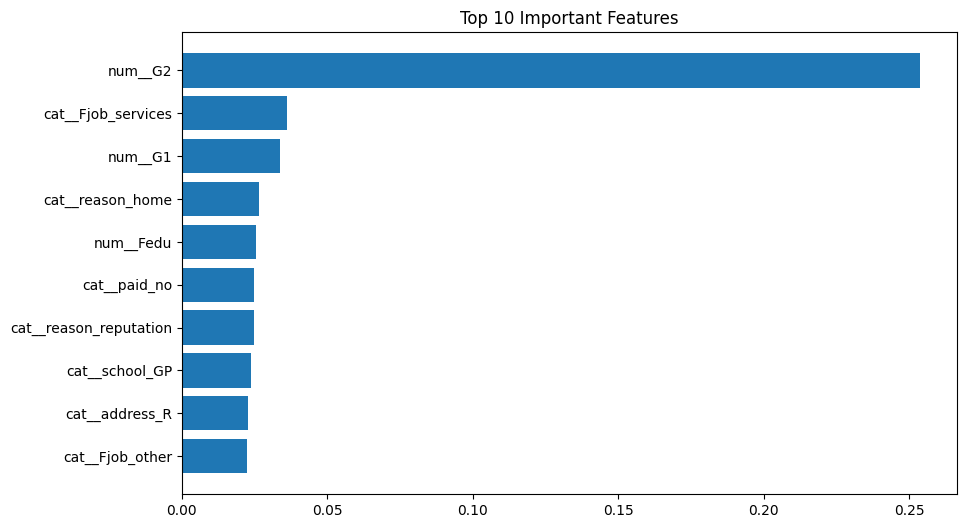

In [104]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()